# Large Raman acquisition viewer — stage-based prototype

This is the offline, Vandermonde-only version of the prototype. Imaging TIFFs and Raman files may live in separate folders. Images and spectra remain on disk until a preview needs them; no GUI or microscope hardware is accessed.

In [5]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Work whether Jupyter starts in this notebook folder or the repository root.
cwd = Path.cwd().resolve()
if (cwd / "large_dataset_viewing.py").exists():
    notebook_dir = cwd
elif (cwd / "notebooks" / "large_dataset_viewing.py").exists():
    notebook_dir = cwd / "notebooks"
else:
    raise RuntimeError("Start Jupyter in napari-raman-widget or its notebooks folder")
sys.path.insert(0, str(notebook_dir))

from large_dataset_viewing import (
    AcquisitionIndex,
    estimated_eager_size,
    fiji_tile_configuration,
    load_vandermonde_geometry,
    plot_raman_on_stitched_image,
    stitch_all_channels_preview,
)

# Imaging and Raman data can be selected independently.
IMAGING_FOLDER = r"C:\Users\spraman\Desktop\Horace\260724_25umthick_lobX\Imaging_2"
RAMAN_FOLDER = r"C:\Users\spraman\Desktop\Horace\260724_25umthick_lobX\raman_1\raman"
SEQUENCE_FILE = r"C:\Users\spraman\Desktop\Horace\260724_25umthick_lobX\Imaging_2\useq-sequence.json"

# Offline objective-specific stage/image geometry.
VANDERMONDE_MODEL = Path(
    r"C:\Users\spraman\Desktop\config\2026_07_23_vandermonde_model.json"
)
OBJECTIVE = "3"
geometry = load_vandermonde_geometry(VANDERMONDE_MODEL, OBJECTIVE)
STAGE_TO_IMAGE = geometry["stage_to_image_pixels_per_um"]

T = 0
Z = 0
MAX_PREVIEW_SIDE = 2048
INVERT_X = False
INVERT_Y = False

## 1. Index the separate folders

Only filenames and sequence metadata are indexed here.

In [6]:
acquisition = AcquisitionIndex.build(
    imaging_folder=IMAGING_FOLDER,
    raman_folder=RAMAN_FOLDER,
    sequence_file=SEQUENCE_FILE,
)
acquisition.summary()

{'imaging_folder': 'C:\\Users\\spraman\\Desktop\\Horace\\260724_25umthick_lobX\\Imaging_2',
 'raman_folder': 'C:\\Users\\spraman\\Desktop\\Horace\\260724_25umthick_lobX\\raman_1\\raman',
 'sequence_file': 'C:\\Users\\spraman\\Desktop\\Horace\\260724_25umthick_lobX\\Imaging_2\\useq-sequence.json',
 'image_files': 150,
 'raman_files': 48624,
 'times': [0],
 'positions': 25,
 'channels': [0, 1, 2],
 'z_planes': [0, 1],
 'image_shape': (1024, 1024)}

## 2. One Raman index beside a selected stitched channel

Set only the Raman index and desired imaging channel. The closest containing image is found automatically, the channel is stitched from stage positions using the Vandermonde transform, and the Raman point is marked on the mosaic. If no image contains the point, the image panel remains empty.

(RamanImageMatch(raman_key=RamanKey(t=0, p=48620, z=0), image_key=ImageKey(t=0, p=13, c=1, z=1), raman_stage_xyz=(17837.780065818242, 449.37167257195506, 4392.35), image_pixel_xy=(837.8816173994943, 365.146708356741), center_distance_pixels=381.705921973255),
 {'t': 0,
  'c': 1,
  'z': 1,
  'tiles': 25,
  'full_resolution_shape': (3830, 4771),
  'preview_shape': (1277, 1591),
  'downsample_stride': 3,
  'pixel_size_um': None,
  'stage_to_image': [[3.11100748254221, 0.015278036444369307],
   [-0.01991029801476368, 3.090133568475157]],
  'invert_x': False,
  'invert_y': False,
  'placement_method': 'stage',
  'raman_index': 48620,
  'raman_marker_xy': (592.6863261873744, 591.2086941279496)})

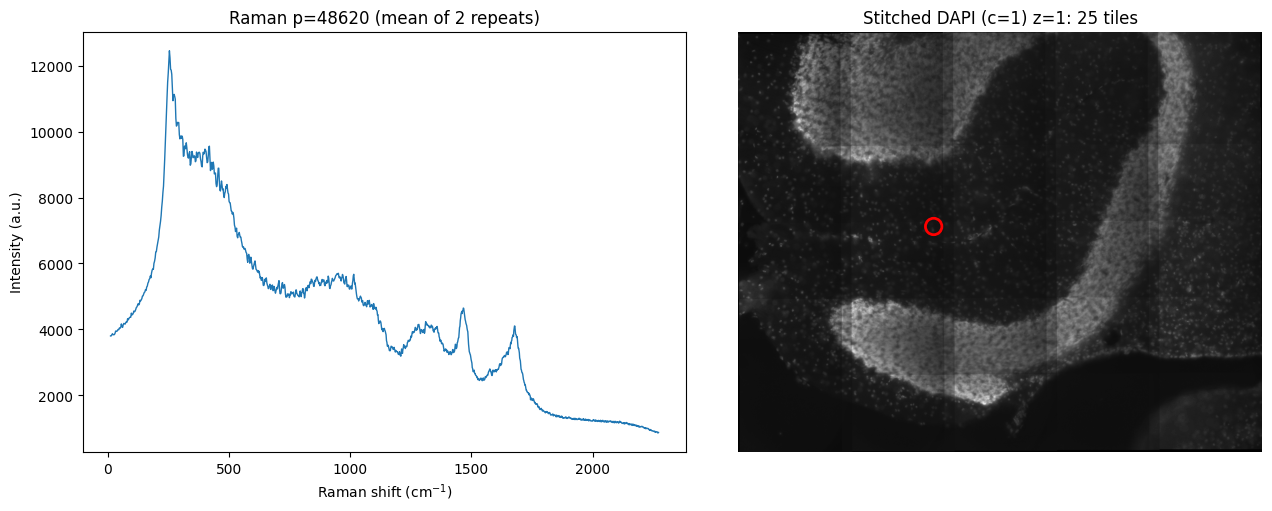

In [9]:
RAMAN_INDEX = 48620
IMAGING_CHANNEL = "DAPI"  # channel name (BF/DAPI/GFP) or c index

figure, match, stitch_metadata = plot_raman_on_stitched_image(
    acquisition,
    RAMAN_INDEX,
    geometry,
    imaging_channel=IMAGING_CHANNEL,
    max_side=MAX_PREVIEW_SIDE,
)
(match, stitch_metadata)

## 3. Stage-position previews for every imaging channel

The preview size is bounded by `MAX_PREVIEW_SIDE`, so this remains usable without constructing a full-resolution in-memory mosaic.

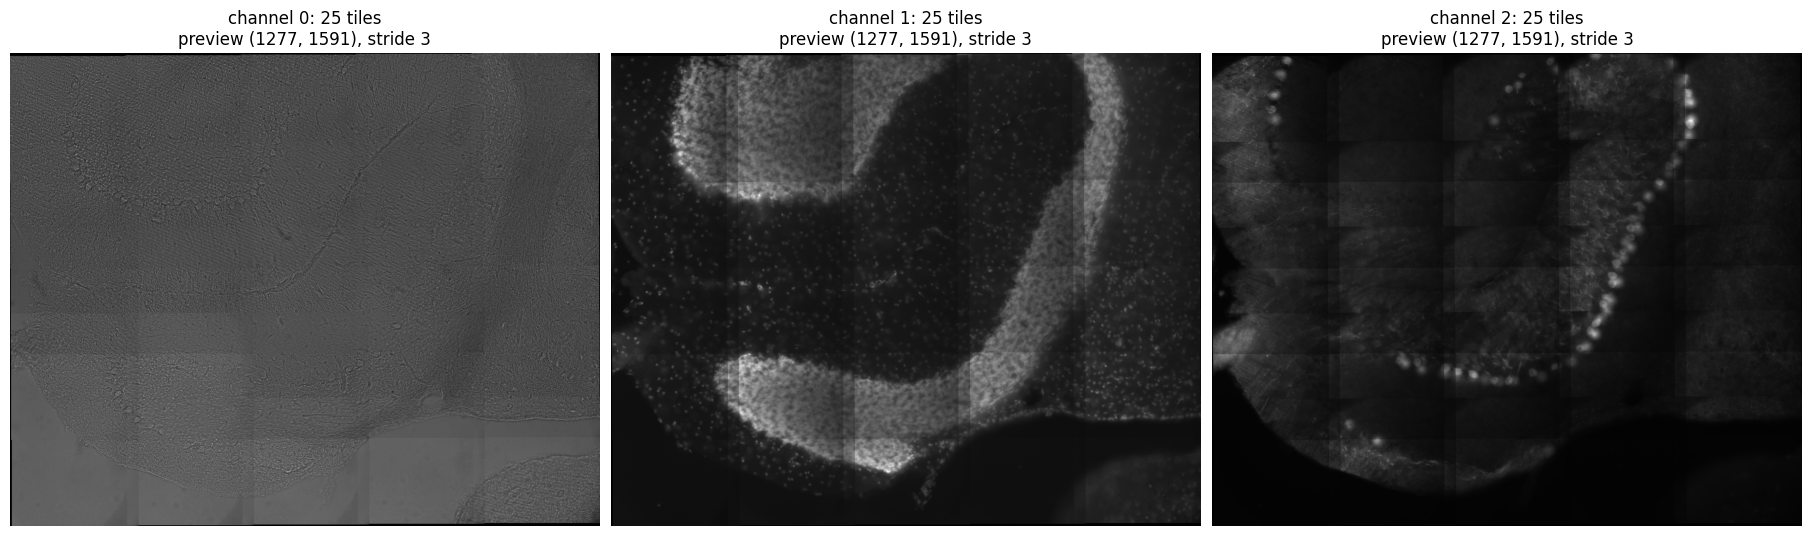

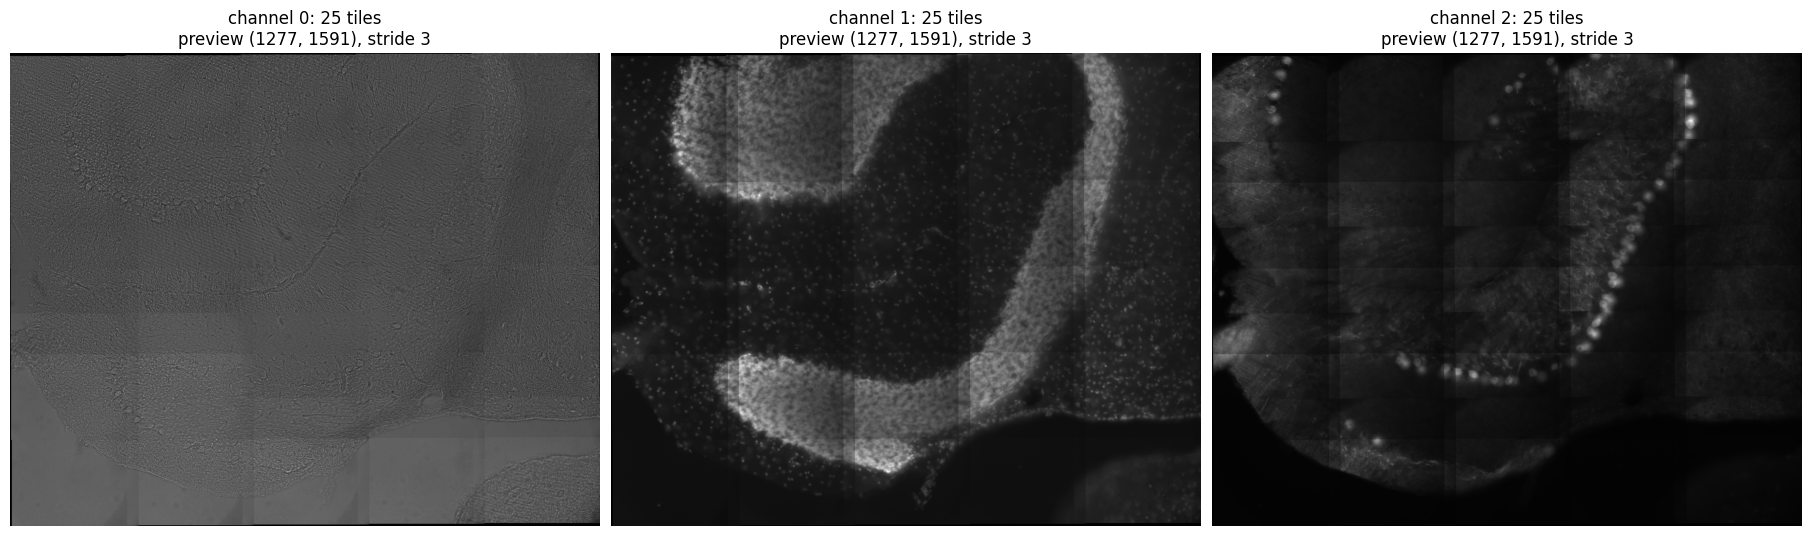

In [8]:
stitched_channels = stitch_all_channels_preview(
    acquisition,
    t=T,
    z=Z,
    stage_to_image=STAGE_TO_IMAGE,
    invert_x=INVERT_X,
    invert_y=INVERT_Y,
    max_side=MAX_PREVIEW_SIDE,
)

figure, axes = plt.subplots(
    1, len(stitched_channels),
    figsize=(6 * len(stitched_channels), 6),
    squeeze=False,
    constrained_layout=True,
)
for axis, (channel, (mosaic, metadata)) in zip(axes[0], stitched_channels.items()):
    axis.imshow(mosaic, cmap="gray")
    axis.set_title(
        f"channel {channel}: {metadata['tiles']} tiles\n"
        f"preview {metadata['preview_shape']}, stride {metadata['downsample_stride']}"
    )
    axis.set_axis_off()
figure

## Notes

- Stitch placement comes only from recorded stage positions and the objective-specific Vandermonde Jacobian.
- There is no MIST registration, flat-field estimation, calibration upload, or correction-library dependency in this version.
- For acquisitions near 100,000 points, keep this indexed/on-demand model: load one Raman file or one bounded mosaic preview at a time rather than stacking the full dataset.